# 1. Project Overview

The general goal of this project is to build a machine learning model that predicts customer churn.

Customer churn is an important business problem because losing existing customers can be more expensive than retaining them. A reliable churn prediction model can help identify customers who are at risk of leaving and support targeted retention strategies.

The project covers the complete machine learning workflow, including:
- data loading and exploration,
- data cleaning and preprocessing,
- feature engineering,
- handling class imbalance,
- train/test splitting,
- cross-validation,
- model comparison,
- hyperparameter optimization,
- classification threshold optimization,
- final model evaluation and error analysis.

The target variable is `churned`, where:
- `0` represents a customer who did not churn,
- `1` represents a customer who churned.

The main goal is to identify as many potential churners as possible while maintaining reasonable prediction quality. For this reason, Recall and the F2 score are treated as important evaluation metrics.

# 2. Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, cross_val_predict, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import RocCurveDisplay, fbeta_score, make_scorer, precision_score, recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay, PrecisionRecallDisplay

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import seaborn as sns
import matplotlib.pyplot as plt

# 3. Load Data and Duplicates

The dataset contains 10,000 observations describing customer demographics, behaviour, account characteristics and churn status. During the initial data inspection, 60 duplicated records associated with 30 duplicated customers were identified. Records with the same `customer_id` contain different demographic or account-related values.

These observations may represent genuine changes during the customer lifecycle, such as relocation, changes in income, subscription updates or changes in customer behaviour. Although some duplicated records could also be caused by data entry issues, they may still contain useful information for predicting churn.

For this reason, the duplicated customer records were retained. Removing them automatically could result in the loss of potentially valuable information and reduce the amount of data available for model training.

In [2]:
data = pd.read_csv("../data/subscription_customers_dirty.csv")

data.head()

,customer_id,age,city,plan,acquisition_channel,join_date,monthly_income_pln,tenure_months,avg_logins_last_30d,support_tickets_last_30d,satisfaction_score,auto_renew,discount_pct,monthly_spend_pln,churned
0,C000001,32,Poznań,Basic,referral,2022-05-21,7500.94,37,15,1,9.0,1,5,149.74,0
1,C000002,38,Łódź,Standard,paid_search,2024-11-26,5549.57,7,0,0,6.0,1,0,94.50,0
2,C000003,39,Warszawa,Basic,referral,2023-05-25,13992.16,25,9,3,6.0,1,0,127.67,0
3,C000004,39,Warszawa,Standard,organic,2022-09-29,8370.21,33,8,0,7.0,1,15,175.89,0
4,C000005,38,Gdańsk,Premium,referral,2025-06-07,9492.17,1,14,0,7.0,1,0,167.46,1


In [4]:
dup_cols = ['customer_id', 'age', 'city', 'plan', 'acquisition_channel', 'join_date']
duplicates = data[data.duplicated(subset=['customer_id'], 
                                  keep=False)].sort_values(by='customer_id')[dup_cols]

print(duplicates)

     customer_id  age      city      plan acquisition_channel   join_date
60       C000061   48   Wrocław  Standard         paid_search  2022-03-05
7447     C000061   26    Kraków   Premium             organic  2025-03-07
5727     C000494   39  Katowice  Standard             organic  2024-01-06
493      C000494   24    Lublin  Standard         paid_search  2024-10-31
884      C000885   41    Lublin     Basic             partner  2024-07-06
3095     C000885   34   Wrocław   Premium         paid_search  2024-10-21
5061     C001389   46  Katowice     Basic         paid_search  2025-06-06
1388     C001389   54    Poznań   Premium            referral  2022-07-17
1528     C001529   42   Wrocław  Standard             organic  2023-07-20
7651     C001529   19      Łódź  Standard             organic  2025-03-18
1942     C001943   31   Wrocław  Standard         paid_search  2022-09-14
1310     C001943   31    Gdańsk  Standard         paid_search  2024-05-12
8056     C002540   36    Gdańsk    Bas

# 4. Data quality & cleaning 

Instead of removing entire rows with data errors they were replaced with `NaN` values.

* `age`: Replaced values $< 18$ or $\ge 99$ with `NaN` to handle outliers and out-of-scope entries.
* `monthly_spend_pln`: Replaced negative values with `NaN`. Rows with missing values in this target variable were dropped followed by an index reset.
* `monthly_income_pln`: Replaced negative values and known sentinel missing code values (`999999`) with `NaN`.

In [5]:
data.drop(columns=['customer_id', 'join_date'], inplace=True)

categorical_cols = ['city', 'plan', 'acquisition_channel']
for col in categorical_cols:
    data[col] = data[col].str.strip().str.lower()

data.loc[
    (data['age'] >= 99) |
    (data['age'] < 18),
    'age'
] = np.nan

data.loc[
    (data['monthly_spend_pln'] < 0),
    'monthly_spend_pln'
] = np.nan

data.loc[
    (data['monthly_income_pln'] < 0) |
    (data['monthly_income_pln'] == 999999),
    'monthly_income_pln'
] = np.nan

data['monthly_spend_pln'].isna().sum()
data = data.dropna(subset=["monthly_spend_pln"]).reset_index(drop=True)

print("Missing values after cleaning:")
display(data.isna().sum().sort_values(ascending=False))

Missing values after cleaning:


monthly_income_pln          157
satisfaction_score          130
city                        109
age                           8
plan                          0
acquisition_channel           0
tenure_months                 0
avg_logins_last_30d           0
support_tickets_last_30d      0
auto_renew                    0
discount_pct                  0
monthly_spend_pln             0
churned                       0
dtype: int64

# 5. Exploratory data analysis

* `data.info()` shows a general overview of the dataset. The dataset contains $9,967$ rows and $13$ columns. It includes both numerical and categorical variables. Some columns contain missing values. The missing values appear in `age`, `city`, `monthly_income_pln` and `satisfaction_score`. The other columns have complete data.

* `data.describe()` presents average customer is about $35$ years old and has been with the company for around $21$ months. The average monthly income is approximately $8,653 PLN$, while the average monthly spend is about $140$ PLN. Most customers log in around $11$ times during the last 30 days. The average satisfaction score is about $7.8$ out of $10$. Most customers also have autom-renew enabled.
The `monthly_spend_pln` variable has a large range, from $0$ to $2,500 PLN$. This may suggest the presence of some unusually high values, that can be outl. The `churned`variable seems to be complete.

* Based on the heat map, `tenure_months`, `satisfaction_score` and `avg_logins_last_30d` appear to have the strongest relationship with `churned`.


In [6]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9997 entries, 0 to 9996
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       9989 non-null   float64
 1   city                      9888 non-null   object 
 2   plan                      9997 non-null   object 
 3   acquisition_channel       9997 non-null   object 
 4   monthly_income_pln        9840 non-null   float64
 5   tenure_months             9997 non-null   int64  
 6   avg_logins_last_30d       9997 non-null   int64  
 7   support_tickets_last_30d  9997 non-null   int64  
 8   satisfaction_score        9867 non-null   float64
 9   auto_renew                9997 non-null   int64  
 10  discount_pct              9997 non-null   int64  
 11  monthly_spend_pln         9997 non-null   float64
 12  churned                   9997 non-null   int64  
dtypes: float64(4), int64(6), object(3)
memory usage: 1015.4+ KB


,age,monthly_income_pln,tenure_months,avg_logins_last_30d,support_tickets_last_30d,satisfaction_score,auto_renew,discount_pct,monthly_spend_pln,churned
count,9989.000000,9840.000000,9997.000000,9997.000000,9997.000000,9867.000000,9997.000000,9997.000000,9997.000000,9997.000000
mean,35.217139,8663.042901,20.793138,10.688306,0.666500,7.807135,0.768731,7.192158,139.985437,0.192658
std,9.652617,3985.200991,12.237488,4.431403,1.055299,1.271001,0.421665,7.459601,66.396193,0.394406
min,18.000000,0.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,5832.465000,10.000000,8.000000,0.000000,7.000000,1.000000,0.000000,109.510000,0.000000
50%,35.000000,7824.505000,21.000000,11.000000,0.000000,8.000000,1.000000,5.000000,138.490000,0.000000
75%,42.000000,10599.945000,31.000000,14.000000,1.000000,9.000000,1.000000,15.000000,166.170000,0.000000
max,71.000000,35000.000000,42.000000,29.000000,12.000000,10.000000,1.000000,20.000000,2500.000000,1.000000


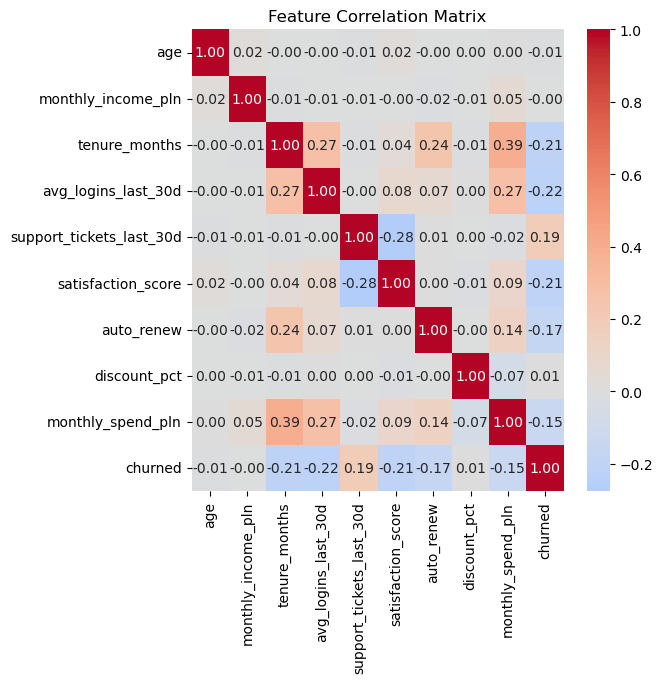

In [7]:
plt.figure(figsize=(6, 6))
sns.heatmap(data.select_dtypes("number").corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f") 
plt.title('Feature Correlation Matrix')
plt.show()

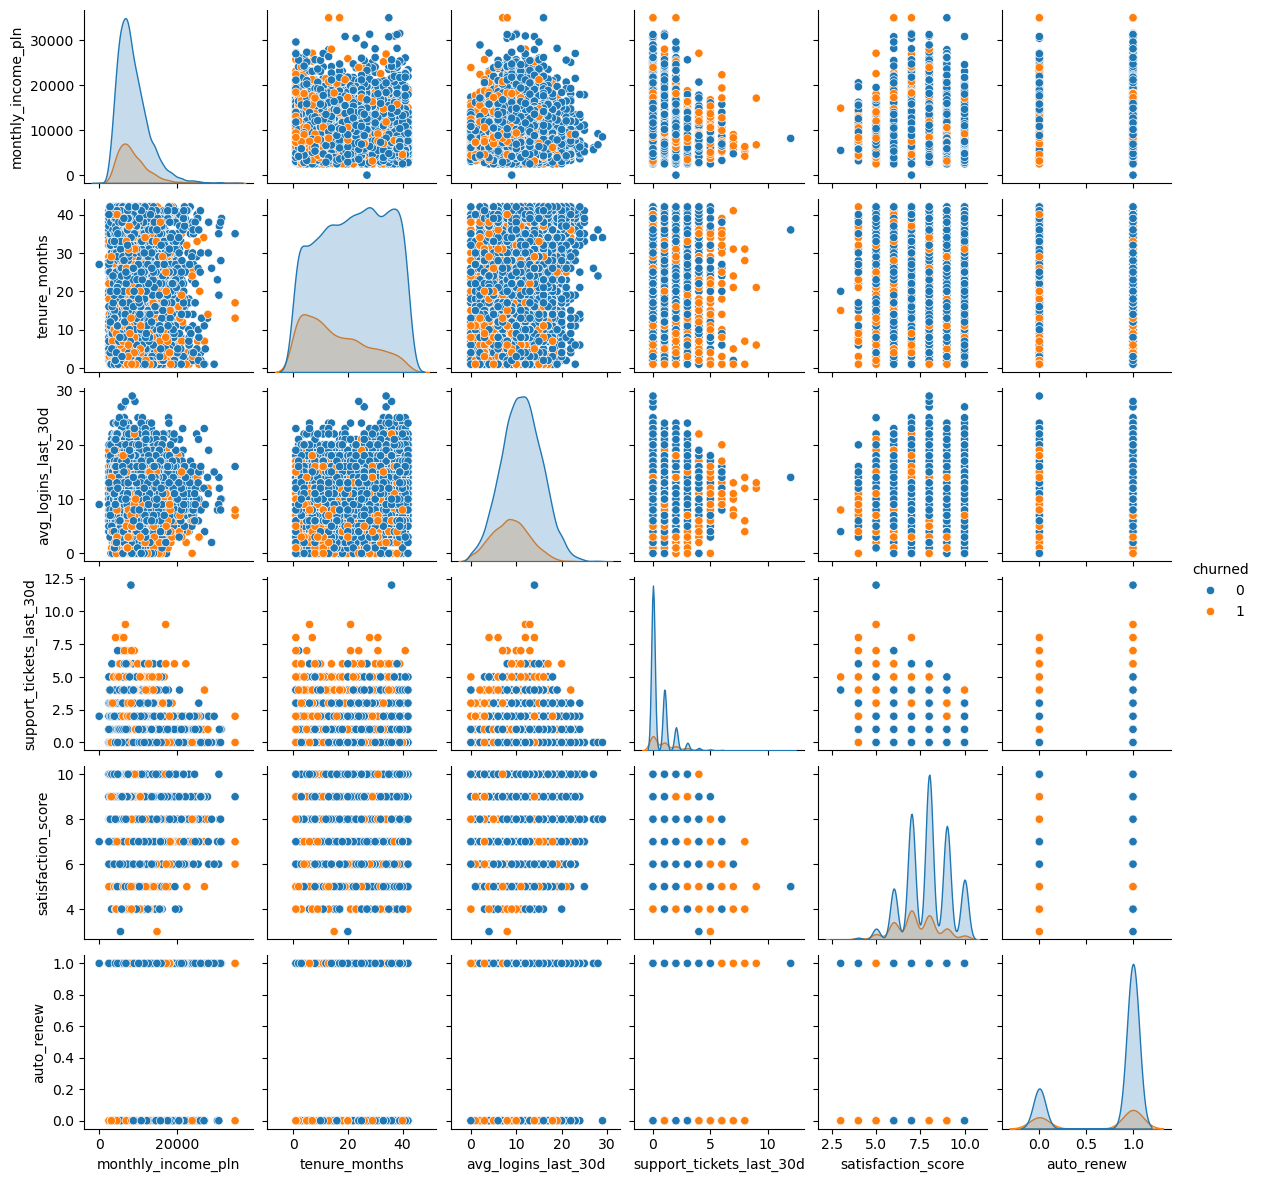

In [8]:
cols = [
    'monthly_income_pln',
    'tenure_months',
    'avg_logins_last_30d',
    'support_tickets_last_30d',
    'satisfaction_score',
    'auto_renew',
    'churned'
]

sns.pairplot(data[cols], hue='churned', height=2)
plt.show()

# 6. Feature engineering and target definition

In this step, the features are separated from the target variable. The target variable is `monthly_spend_pln`, so it is removed from input features. Churned was also excluded because it represents an outcome that may occur after or be directly related to the prediction period. Including it could introduce target leakage depending on when the feature is observed

The `satisfaction_per_tenure` feature was created to capture how a customer's satisfaction evolves relative to their loyalty, helping the model identify long-term clients whose satisfaction might be declining despite their extended tenure

The `high_spend` variable contains `monthly_spend_pln values` ​​with values ​​above 500. There are 5 such records that have the same value of 2500. They could be treated as erroneous data however such values ​​are theoretically possible, and the remaining feature columns do not contain errors in the data.

In [9]:
X = data.drop(columns=[
    "monthly_spend_pln",
    "churned"
])
y = data["churned"]

X["satisfaction_per_tenure"] = (
    X["satisfaction_score"] / (X["tenure_months"] + 1)
)

X["satisfaction_per_tenure"]

high_spend = data["monthly_spend_pln"] >= 500
data[high_spend]

,age,city,plan,acquisition_channel,monthly_income_pln,tenure_months,avg_logins_last_30d,support_tickets_last_30d,satisfaction_score,auto_renew,discount_pct,monthly_spend_pln,churned
2388,47.0,wrocław,standard,social,10716.70,10,6,1,9.0,0,10,2500.0,0
2933,36.0,lublin,basic,organic,2840.60,12,16,0,6.0,0,20,2500.0,1
3272,42.0,łódź,basic,paid_search,14278.43,37,11,2,7.0,1,10,2500.0,0
3371,19.0,lublin,standard,paid_search,10223.06,28,6,0,8.0,1,0,2500.0,0
9698,33.0,kraków,standard,organic,7617.57,11,9,1,NaN,0,20,2500.0,0


# 7. Train/test split

The dataset was divided into training and test sets using a standard train/test split.

The training set is used for model development, cross-validation, hyperparameter optimization and threshold optimization. The test set is kept separate and is used only for the final evaluation of the selected model. In that way it is possible to avoid data leackage.

Since the target classes are imbalanced, `stratify=y` was used during the split. This helps preserve a similar proportion of churned and non-churned customers in both the training and test sets.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

# 8. Preprocessing pipeline

For numerical features, missing values are replaced with the median and the values are standardized.
For categorical features, missing values are replaced with the most frequent value. Then, categorical variables are converted into numerical values using one-hot encoding.

All preprocessing steps are placed inside a scikit-learn pipeline. This makes sure that the preprocessing is fitted only on the training data and to avoid data leackage.

In [11]:
reg_numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')),
                                    ('scaler', StandardScaler())])
reg_categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
numeric_selector = make_column_selector(dtype_include="number")
categorical_selector = make_column_selector(dtype_include="object")

preprocessor = ColumnTransformer([('num', reg_numeric_transformer, numeric_selector),
                                 ('cat', reg_categorical_transformer, categorical_selector)])

In [12]:
pipelines = { 
    "Logistic Regression": Pipeline([('preprocessor', preprocessor), ('classifier', LogisticRegression())]), 
    "Decision Tree": Pipeline([('preprocessor', preprocessor), ('classifier', DecisionTreeClassifier())]), 
    "Random Forest": Pipeline([('preprocessor', preprocessor), ('classifier', RandomForestClassifier())]), 
    "KN": Pipeline([('preprocessor', preprocessor), ('classifier', KNeighborsClassifier())]), 
    "SVC": Pipeline([('preprocessor', preprocessor), ('classifier', SVC())]), 
    "XGB": Pipeline([('preprocessor', preprocessor), ('classifier', XGBClassifier())]),
    "Gradient Boosting": Pipeline([('preprocessor', preprocessor), ('classifier', GradientBoostingClassifier())]),
    "LGBM": Pipeline([('preprocessor', preprocessor), ('classifier', LGBMClassifier())])
}

# 9. Stratified cross-validation

Stratified 5-fold cross-validation was used to evaluate and compare the classification models.

Because the target classes are imbalanced, `StratifiedKFold` was selected instead of a standard `KFold`. Stratification helps maintain a similar proportion of churned and non-churned customers in each fold, making the evaluation more stable and representative.

Accuracy was not used as the main evaluation metric because it can be misleading when one class is more frequent than the other. Instead, the models were evaluated using:

- Precision,
- Recall,
- F1 score,
- F2 score,
- ROC-AUC.

The F2 score was included because the project focuses on identifying customers who are likely to churn. Compared with the F1 score, F2 gives more importance to Recall.

The cross-validation results show different trade-offs between Precision and Recall. Logistic Regression achieved the highest ROC-AUC score, indicating the strongest overall ability to distinguish between churned and non-churned customers. However, Decision Tree achieved the highest Recall and F2 score during the initial model comparison.

These results show that model selection should not be based on a single metric. The next step is hyperparameter optimization of the most promising models.

In [13]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

f2_scorer = make_scorer(
    fbeta_score,
    beta=2,
    zero_division=0
)

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "f2": f2_scorer,
    "roc_auc": "roc_auc"
}

cv_results = []

for name, model in pipelines.items():
    
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV F2": scores["test_f2"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

comparison_cv = (
    pd.DataFrame(cv_results)
    .sort_values("CV F2", ascending=False)
    .reset_index(drop=True)
)

comparison_cv

,Model,CV Precision,CV Recall,CV F1,CV F2,CV ROC-AUC
0,Decision Tree,0.300815,0.328370,0.313572,0.322173,0.573493
1,XGB,0.465589,0.223240,0.301079,0.248922,0.713391
2,LGBM,0.524205,0.206367,0.295566,0.234658,0.738493
3,Gradient Boosting,0.580787,0.196633,0.293461,0.226512,0.754797
4,Logistic Regression,0.621865,0.194711,0.295655,0.225463,0.763304
5,KN,0.431891,0.192103,0.265489,0.215953,0.658321
6,Random Forest,0.551300,0.140178,0.223042,0.164628,0.732882
7,SVC,0.644289,0.116812,0.197540,0.139632,0.686309


# 10. Hyperparameter optimization with RandomizedSearchCV

The most promising models were selected for hyperparameter optimization:
- Logistic Regression,
- Decision Tree,
- XGBoost,
- LightGBM.

`RandomizedSearchCV` was used to test different combinations of hyperparameters using stratified cross-validation.

The F2 score was used as the optimization metric because the main objective of the project is to identify as many churned customers as possible. This metric gives greater importance to Recall while still considering Precision.

After hyperparameter optimization, Logistic Regression achieved the highest cross-validation F2 score of approximately 0.58. Decision Tree achieved the second-best result, while the optimized XGBoost and LightGBM models produced lower F2 scores. Based on these results, Logistic Regression and Decision Tree were selected as the leading candidates for further threshold optimization.

In [14]:
optimization_pipelines = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "XGB": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ))
    ]),

    "LGBM": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LGBMClassifier(
            random_state=42,
            verbosity=-1
        ))
    ]),
        
     "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
        ))
    ])
}

In [15]:
param_distributions = {

    "Logistic Regression": {
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__solver": ["liblinear", "lbfgs"],
        "classifier__class_weight": [None, "balanced"]
    },

    "XGB": {
        "classifier__n_estimators": [100, 200, 300, 500],
        "classifier__max_depth": [3, 4, 5, 6, 8],
        "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "classifier__subsample": [0.7, 0.8, 1.0],
        "classifier__colsample_bytree": [0.7, 0.8, 1.0]
    },

    "LGBM": {
        "classifier__n_estimators": [100, 200, 300, 500],
        "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "classifier__max_depth": [-1, 3, 5, 7, 10],
        "classifier__num_leaves": [15, 31, 50, 75],
        "classifier__min_child_samples": [10, 20, 30, 50],
        "classifier__subsample": [0.7, 0.8, 1.0],
        "classifier__colsample_bytree": [0.7, 0.8, 1.0]
    },
    
    "Decision Tree": {
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [None, 3, 5, 7, 10, 15, 20],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5, 10],
    "classifier__max_features": [None, "sqrt", "log2"],
    "classifier__class_weight": [None, "balanced"]
},
}

In [16]:
best_models = {}
optimization_results = []

for name in optimization_pipelines:

    print(f"Optimizing {name}...")

    search = RandomizedSearchCV(
        estimator=optimization_pipelines[name],
        param_distributions=param_distributions[name],
        n_iter=30,
        scoring=f2_scorer,
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)

    best_models[name] = search.best_estimator_

    optimization_results.append({
        "Model": name,
        "Best CV F2": search.best_score_,
    })

Optimizing Logistic Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 20 is smaller than n_iter=30. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Optimizing XGB...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Optimizing LGBM...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Optimizing Decision Tree...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [17]:
optimization_results_df = (
    pd.DataFrame(optimization_results)
    .sort_values("Best CV F2", ascending=False)
    .reset_index(drop=True)
)

optimization_results_df

,Model,Best CV F2
0,Logistic Regression,0.579641
1,Decision Tree,0.538352
2,XGB,0.269341
3,LGBM,0.268609


# 11. Threshold optimization

Classification models usually use a default probability threshold of 0.50.

However, the default threshold is not always optimal for the business objective. In this project, missing a customer who is likely to churn is considered more important than generating some additional false positive predictions.

For this reason, different classification thresholds were tested using out-of-fold predicted probabilities from the training set. The threshold that produced the highest F2 score was selected for each optimized model.

Logistic Regression achieved the best result with a threshold of 0.35 and an optimized cross-validation F2 score of 0.61. Lowering the threshold increases the model's sensitivity to potential churners. This can improve Recall, but it may also increase the number of false positive predictions and reduce Precision.

The selected threshold represents a trade-off that is consistent with the main objective of the project: identifying as many customers at risk of churn as possible.

In [18]:
threshold_results = []

thresholds = np.arange(0.10, 0.91, 0.01)

models_threshold = ["Logistic Regression", "Decision Tree"]

for name in models_threshold:

    model = best_models[name]

    y_proba_oof = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    f2_scores = [
        fbeta_score(
            y_train,
            (y_proba_oof >= t).astype(int),
            beta=2,
            zero_division=0
        )
        for t in thresholds
    ]

    best_idx = np.argmax(f2_scores)

    threshold_results.append({
        "Model": name,
        "Best Threshold": thresholds[best_idx],
        "Optimized CV F2": f2_scores[best_idx]
    })

threshold_results_df = (
    pd.DataFrame(threshold_results)
    .sort_values("Optimized CV F2", ascending=False)
    .reset_index(drop=True)
)

threshold_results_df

,Model,Best Threshold,Optimized CV F2
0,Logistic Regression,0.35,0.608120
1,Decision Tree,0.26,0.576424


# 12. Final model evaluation

The final Logistic Regression model was trained on the full training set using the optimized hyperparameters.
The optimized classification threshold of 0.35 was then applied to predicted probabilities from the previously unseen test set.

The final model achieved:

- Precision: 0.27
- Recall: 0.84
- F1 score: 0.41
- F2 score: 0.59
- ROC-AUC: 0.75

The model achieved a high Recall score, meaning that it successfully identified approximately 84% of customers who actually churned.

However, this improvement comes at the cost of lower Precision. The model classifies more customers as potential churners, which increases the number of false positive predictions.

This trade-off is expected because the classification threshold was optimized for the F2 score, which gives greater importance to Recall.

In [20]:
best_model_name = threshold_results_df.iloc[0]["Model"]
best_threshold = threshold_results_df.iloc[0]["Best Threshold"]
final_model = best_models[best_model_name]

final_model.fit(X_train, y_train)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

y_test_pred = (
    y_test_proba >= best_threshold
).astype(int)

final_model.predict(X_test)

array([0, 0, 0, ..., 0, 1, 1], dtype=int64)

In [21]:
final_results = pd.DataFrame([{
    "Model": best_model_name,
    "Threshold": best_threshold,
    "Precision": precision_score(
        y_test,
        y_test_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_test_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        y_test_pred,
        zero_division=0
    ),
    "F2": fbeta_score(
        y_test,
        y_test_pred,
        beta=2,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_test_proba
    )
}])

final_results

,Model,Threshold,Precision,Recall,F1,F2,ROC-AUC
0,Logistic Regression,0.35,0.268557,0.836364,0.406566,0.587806,0.753342


## 12.1 Default vs Optimized Classification Threshold

The performance of the final model was compared using the default threshold of 0.50 and the optimized threshold of 0.35. The default threshold is not necessarily the best choice when the business objective prioritizes identifying the positive class.

Lowering the threshold increased Recall from 0.68 to 0.84. This means that the optimized model identified more customers who actually churned. At the same time, Precision decreased from approximately 0.36 to 0.27, meaning that more non-churning customers were incorrectly classified as potential churners.

The F2 score increased from approximately 0.57 to 0.59, confirming that the optimized threshold is more suitable for the objective of this project.

In [22]:
y_test_pred_default = (
    y_test_proba >= 0.5
).astype(int)

threshold_comparison = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1",
        "F2"
    ],
    
    "Default Threshold (0.50)": [
        precision_score(y_test, y_test_pred_default),
        recall_score(y_test, y_test_pred_default),
        f1_score(y_test, y_test_pred_default),
        fbeta_score(y_test, y_test_pred_default, beta=2)
    ],
    
    f"Optimized Threshold ({best_threshold:.2f})": [
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0),
        fbeta_score(
            y_test,
            y_test_pred,
            beta=2,
            zero_division=0
        )
    ]
})

threshold_comparison

,Metric,Default Threshold (0.50),Optimized Threshold (0.35)
0,Precision,0.355191,0.268557
1,Recall,0.675325,0.836364
2,F1,0.465533,0.406566
3,F2,0.572183,0.587806


## 12.2 Confusion Matrix

The confusion matrix was calculated using predictions from the previously unseen test set and the optimized classification threshold of 0.35.

The model correctly classified:

- 738 customers as not churned,
- 322 customers as churned.

The model missed 63 customers who actually churned. These cases represent false negatives.

The model also classified 877 customers as churn risks even though they did not churn. These cases represent false positives.

The relatively high number of false positives is a consequence of lowering the classification threshold. The model becomes more sensitive to potential churners, which increases Recall but reduces Precision.

From a churn prediction perspective, the final model successfully identifies most customers who actually churn. However, a business using this model would need to consider the cost of taking retention actions for customers who would not have churned.

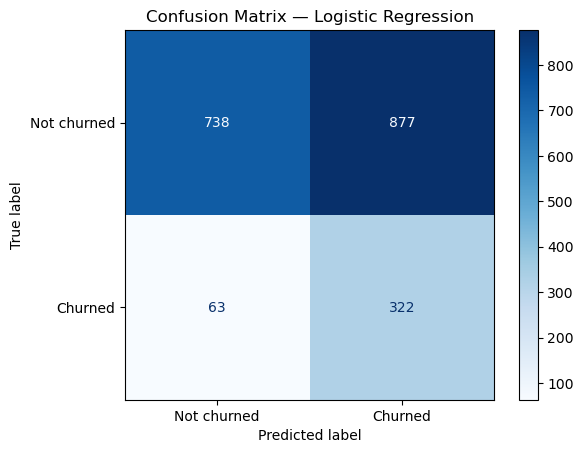

In [23]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    cmap=plt.cm.Blues,
    display_labels=[
        "Not churned",
        "Churned"
    ]
)
plt.title(
    f"Confusion Matrix — {best_model_name}"
)
plt.show()

## 12.3  Precision-Recall Curve

The Precision-Recall curve shows the relationship between Precision and Recall across different classification thresholds. The curve illustrates a clear trade-off between the two metrics. Increasing Recall requires the model to classify more customers as potential churners, which results in lower Precision.

The selected threshold of 0.35 represents a point where Recall is prioritized over Precision. This decision is consistent with the use of the F2 score as the main optimization metric.

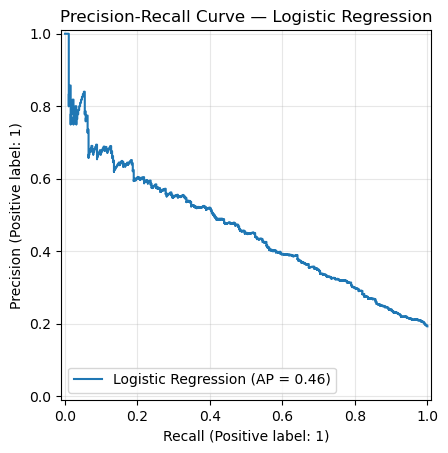

In [24]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_proba,
    name=best_model_name
)
plt.title(
    f"Precision-Recall Curve — {best_model_name}"
)
plt.grid(alpha=0.3)
plt.show()

## 12.4 ROC Curve

The ROC curve evaluates the model's ability to distinguish between churned and non-churned customers across different classification thresholds.

The final Logistic Regression model achieved a ROC-AUC score of approximately 0.75.

This indicates that the model has a reasonable ability to rank customers according to their likelihood of churn. However, ROC-AUC does not show the specific trade-off between Precision and Recall, which is especially important for an imbalanced churn classification problem.

For this reason, ROC-AUC is interpreted together with the Precision-Recall curve and the F2 score.

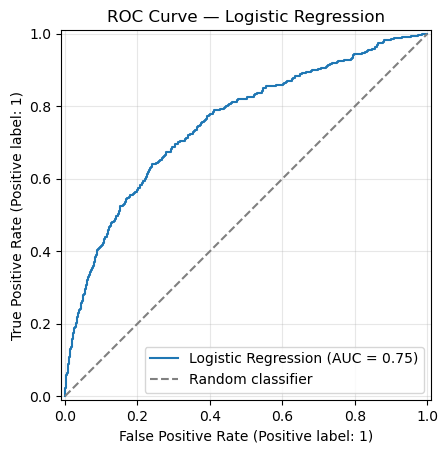

In [25]:
RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba,
    name=best_model_name
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier"
)

plt.title(
    f"ROC Curve — {best_model_name}"
)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 13. Final Model Diagnostics

Model diagnostics were performed to better understand the behaviour of the final Logistic Regression model. Since Logistic Regression is an interpretable model, the model coefficients can be used to analyse the relationship between input features and the probability of customer churn.

Positive coefficients indicate features associated with a higher predicted probability of churn, while negative coefficients indicate features associated with a lower predicted probability of churn.

The second chart shows that setting a low classification threshold of 0.35 prioritizes catching most at-risk customers (high Recall) to prevent them from leaving. However, this strategy leads to a large number of false alarms, meaning many loyal customers will accidentally receive unnecessary retention offers. Ultimately, this approach is ideal if losing a customer is highly expensive, but the threshold should be raised if the budget for retention campaigns is limited.

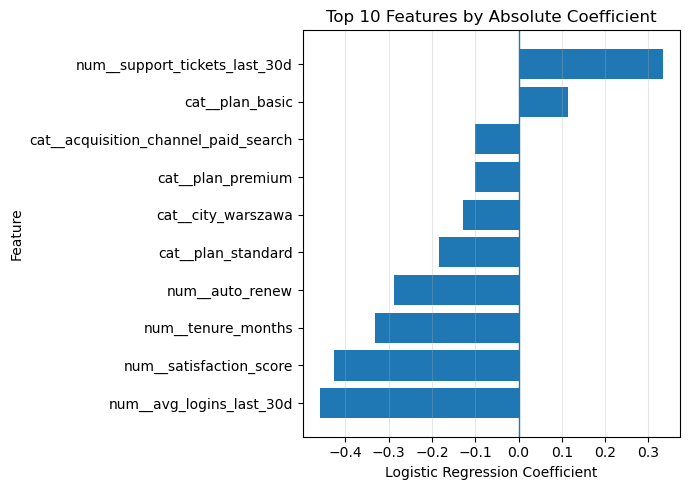

In [44]:
preprocessor_fitted = final_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()
model_coef = final_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model_coef,
    "Absolute Coefficient": np.abs(coefficients)
}).sort_values(
    "Absolute Coefficient",
    ascending=False
).reset_index(drop=True)

top_n = 10

top_features = (
    coef_df
    .head(top_n)
    .sort_values("Coefficient")
)

plt.figure(figsize=(7, 5))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Features by Absolute Coefficient")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

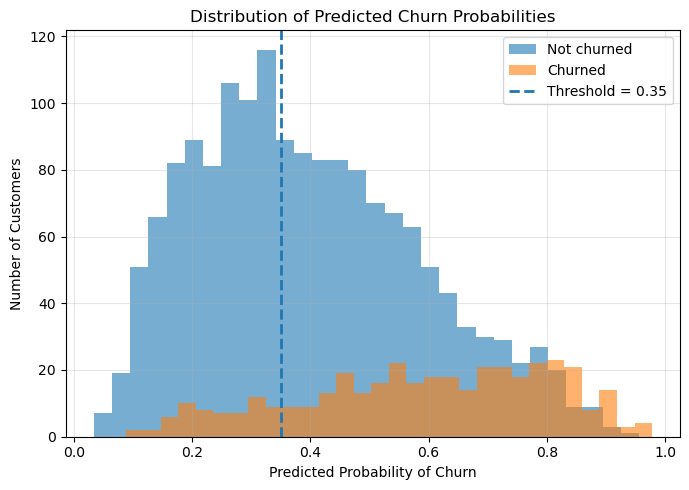

In [45]:
plt.figure(figsize=(7, 5))

plt.hist(
    y_test_proba[y_test == 0],
    bins=30,
    alpha=0.6,
    label="Not churned"
)

plt.hist(
    y_test_proba[y_test == 1],
    bins=30,
    alpha=0.6,
    label="Churned"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {best_threshold:.2f}"
)

plt.xlabel("Predicted Probability of Churn")
plt.ylabel("Number of Customers")
plt.title("Distribution of Predicted Churn Probabilities")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 14. Error analysis

The final model was analysed to better understand its prediction errors.
Two types of classification errors are particularly important:

- FP: customers predicted to churn who did not actually churn - they are important because the company wastes money on retention offers for customers who were going to stay anyway.
- FN: customers predicted not to churn who actually churned - they are critical because these are the customers that we fail to save before they leave

TP customers are newer accounts (14 months) with lower satisfaction, fewer logins, and higher support tickets, making their churn risk easily detectable by the model. In contrast, FN clients represent long-term, highly active, and satisfied users who leave without contacting support, tricking the model into classifying them as safe. This reveals a critical blind spot in predicting churn among loyal, quiet customers despite their stable spending habits.

The chart demonstrates effective risk differentiation, assigning the highest average churn probability to TP (0.66) and the lowest to TN (0.23). A clear separation exists between positive and negative predictions due to the 0.35 threshold. Additionally, FN (0.25) appear close to the threshold, indicating that the model classified these overlooked customers as borderline cases rather than entirely safe.

In [36]:
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = y_test_pred
error_analysis["Predicted Probability"] = y_test_proba


def classify_prediction(row):
    if row["Actual"] == 1 and row["Predicted"] == 1:
        return "True Positive"
    elif row["Actual"] == 0 and row["Predicted"] == 0:
        return "True Negative"
    elif row["Actual"] == 0 and row["Predicted"] == 1:
        return "False Positive"
    else:
        return "False Negative"


error_analysis["Prediction Type"] = error_analysis.apply(
    classify_prediction,
    axis=1
)

In [39]:
features_to_compare = [
    "tenure_months",
    "satisfaction_score",
    "avg_logins_last_30d",
    "support_tickets_last_30d",
    "monthly_income_pln",
]

fn_tp_comparison = (
    error_analysis[
        error_analysis["Prediction Type"].isin(
            ["False Negative", "True Positive"]
        )
    ]
    .groupby("Prediction Type")[features_to_compare]
    .mean()
)

fn_tp_comparison

,tenure_months,satisfaction_score,avg_logins_last_30d,support_tickets_last_30d,monthly_income_pln
Prediction Type,,,,,
False Negative,26.793651,8.476190,12.634921,0.222222,8645.043333
True Positive,14.114907,7.120253,7.996894,1.211180,8687.326772


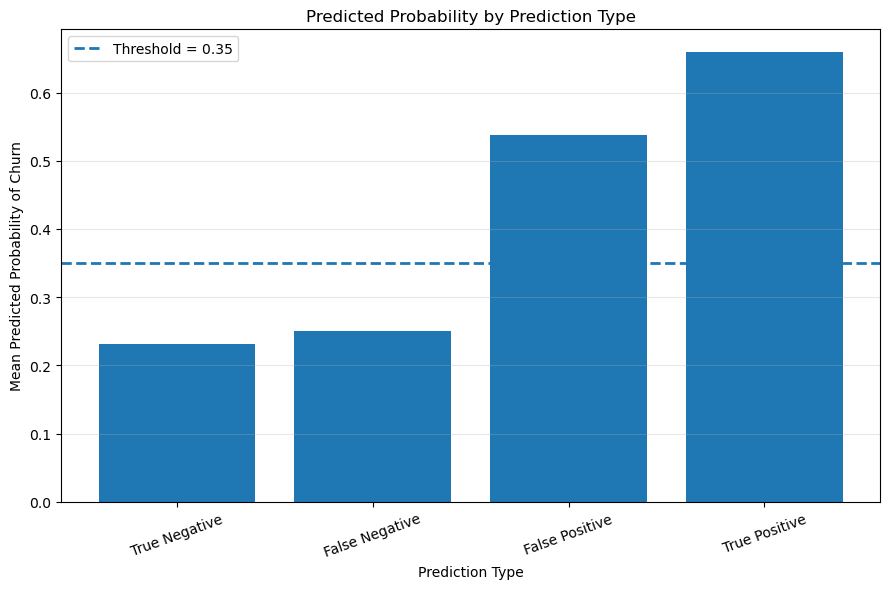

In [33]:
probability_summary = (
    error_analysis
    .groupby("Prediction Type")["Predicted Probability"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(9, 6))

plt.bar(
    probability_summary.index,
    probability_summary.values
)

plt.axhline(
    best_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {best_threshold:.2f}"
)

plt.xlabel("Prediction Type")
plt.ylabel("Mean Predicted Probability of Churn")
plt.title("Predicted Probability by Prediction Type")

plt.xticks(rotation=20)
plt.legend()

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 15. Final Conclusions and Business Recommendations